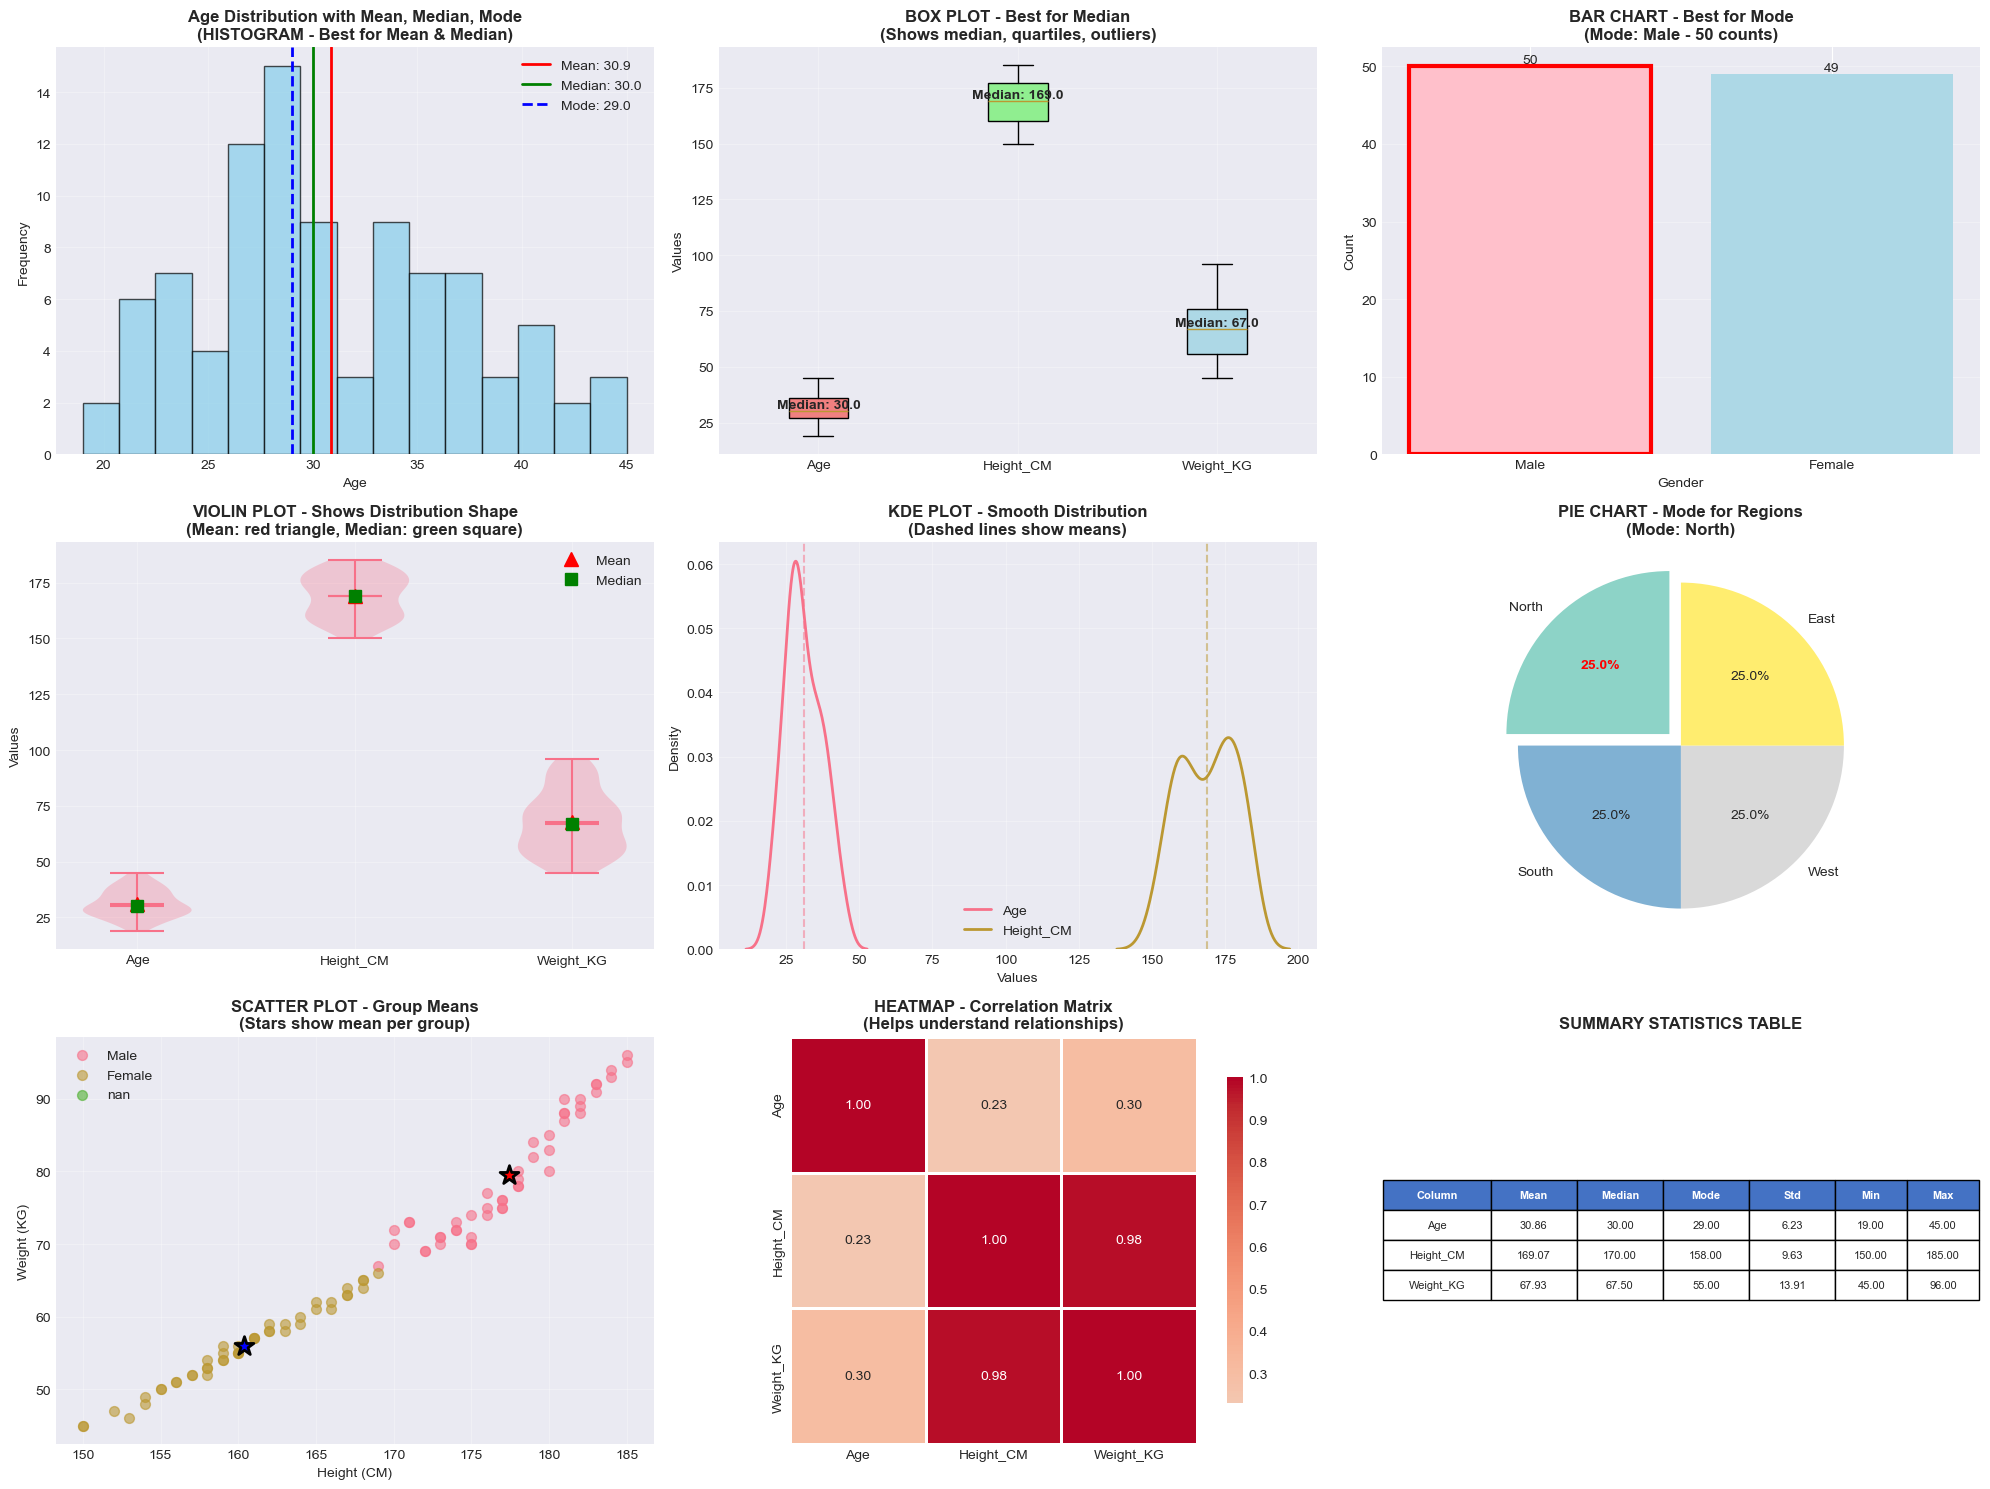

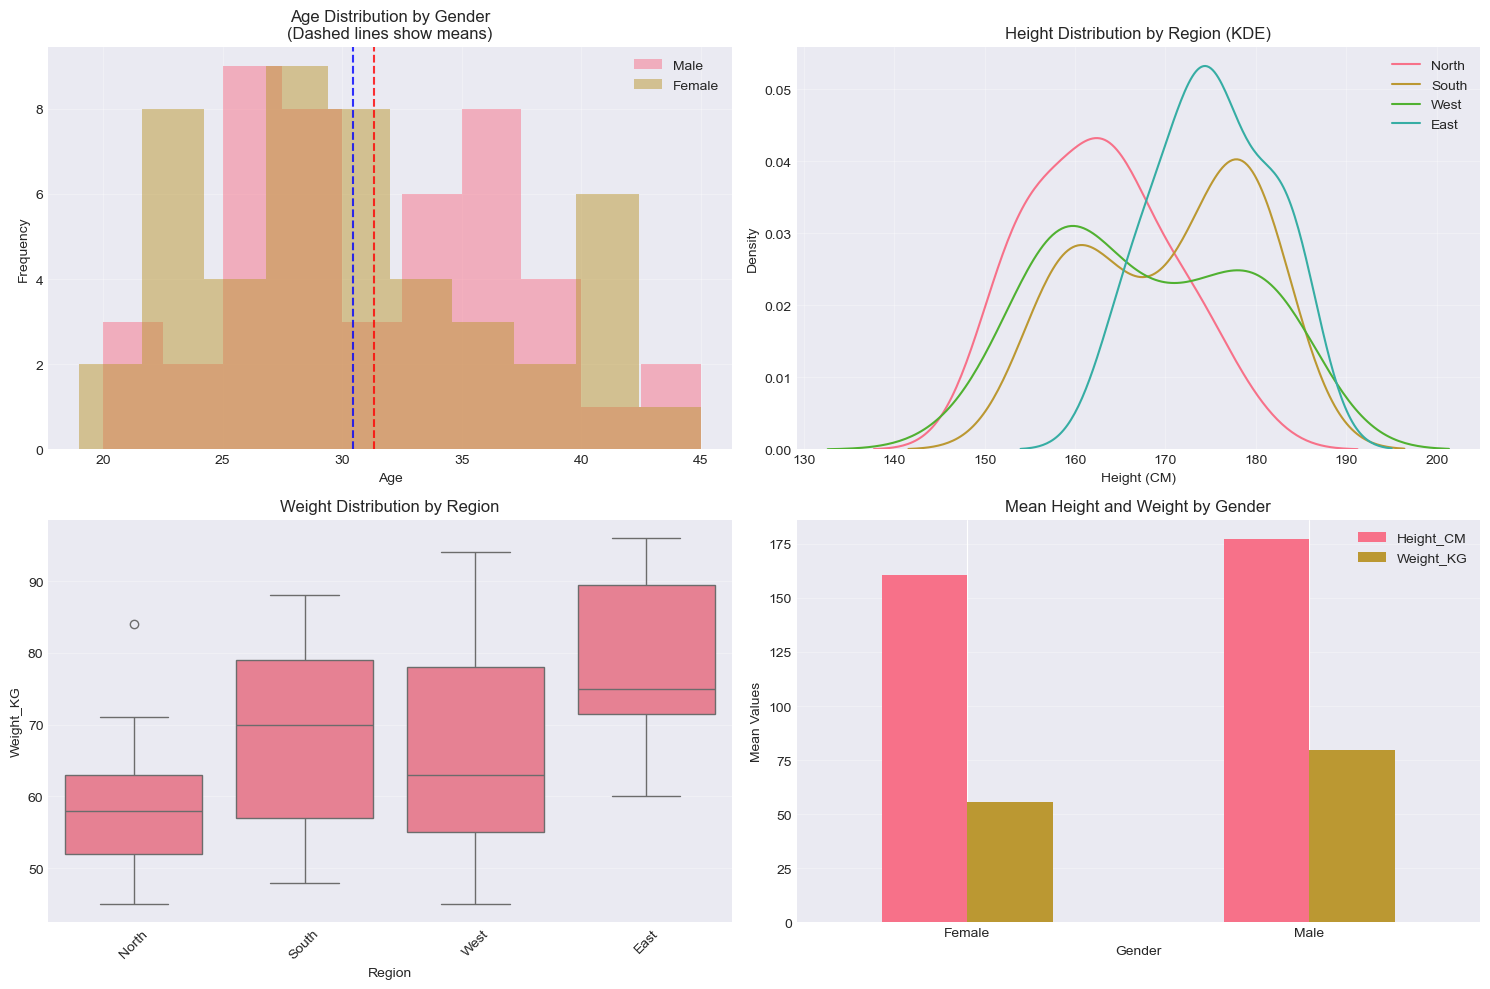


DETAILED STATISTICAL SUMMARY

AGE:
  Mean: 30.86
  Median: 30.00
  Mode: [29.]
  Standard Deviation: 6.23
  Min: 19.00
  Max: 45.00
  Range: 26.00
  Count: 94
  Missing: 6

HEIGHT_CM:
  Mean: 169.07
  Median: 170.00
  Mode: [158. 159. 160. 175. 177. 178. 181.]
  Standard Deviation: 9.63
  Min: 150.00
  Max: 185.00
  Range: 35.00
  Count: 95
  Missing: 5

WEIGHT_KG:
  Mean: 67.93
  Median: 67.50
  Mode: [55. 58. 70.]
  Standard Deviation: 13.91
  Min: 45.00
  Max: 96.00
  Range: 51.00
  Count: 98
  Missing: 2

CATEGORICAL MODE
Country: Mode = 'India' (appears 15 times)
Region: Mode = 'East' (appears 25 times)
Gender: Mode = 'Male' (appears 50 times)


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the data
df = pd.read_csv('dataset1.csv')

# Create a figure with subplots for different visualizations
fig = plt.figure(figsize=(20, 15))

# 1. HISTOGRAM WITH MEAN, MEDIAN, MODE - Best for Mean & Median
ax1 = plt.subplot(3, 3, 1)
# Clean data for Age (remove NaN)
age_clean = df['Age'].dropna()

# Plot histogram
ax1.hist(age_clean, bins=15, edgecolor='black', alpha=0.7, color='skyblue')

# Add mean, median, mode lines
mean_age = age_clean.mean()
median_age = age_clean.median()
mode_age = age_clean.mode()[0]

ax1.axvline(mean_age, color='red', linewidth=2, label=f'Mean: {mean_age:.1f}')
ax1.axvline(median_age, color='green', linewidth=2, label=f'Median: {median_age:.1f}')
ax1.axvline(mode_age, color='blue', linewidth=2, linestyle='--', label=f'Mode: {mode_age:.1f}')

ax1.set_title('Age Distribution with Mean, Median, Mode\n(HISTOGRAM - Best for Mean & Median)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Age')
ax1.set_ylabel('Frequency')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. BOX PLOT - Best for Median (shows quartiles)
ax2 = plt.subplot(3, 3, 2)
# Box plot for multiple numerical columns
numerical_cols = ['Age', 'Height_CM', 'Weight_KG']
df_clean = df[numerical_cols].dropna()

box_plot = ax2.boxplot([df_clean[col] for col in numerical_cols], 
                        labels=numerical_cols, patch_artist=True)

# Color the boxes
colors = ['lightcoral', 'lightgreen', 'lightblue']
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)

# Add median values on plot
for i, col in enumerate(numerical_cols):
    median_val = df_clean[col].median()
    ax2.text(i+1, median_val, f'Median: {median_val:.1f}', 
             ha='center', va='bottom', fontweight='bold')

ax2.set_title('BOX PLOT - Best for Median\n(Shows median, quartiles, outliers)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Values')
ax2.grid(True, alpha=0.3)

# 3. BAR CHART - Best for Mode (categorical data)
ax3 = plt.subplot(3, 3, 3)
# Count plot for Gender (categorical)
gender_counts = df['Gender'].value_counts()
mode_gender = gender_counts.index[0]

bars = ax3.bar(gender_counts.index, gender_counts.values, color=['pink', 'lightblue'])

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom')

# Highlight the mode bar
bars[0].set_edgecolor('red')
bars[0].set_linewidth(3)

ax3.set_title(f'BAR CHART - Best for Mode\n(Mode: {mode_gender} - {gender_counts.max()} counts)', 
              fontsize=12, fontweight='bold')
ax3.set_xlabel('Gender')
ax3.set_ylabel('Count')
ax3.grid(True, alpha=0.3, axis='y')

# 4. VIOLIN PLOT - Combines box plot and density (shows all three)
ax4 = plt.subplot(3, 3, 4)
# Prepare data for violin plot
df_melted = pd.melt(df_clean, value_vars=numerical_cols)

violin_parts = ax4.violinplot([df_clean[col].dropna() for col in numerical_cols], 
                              positions=[1, 2, 3], showmeans=True, showmedians=True)

# Add mean and median markers
for i, col in enumerate(numerical_cols):
    data = df_clean[col].dropna()
    mean_val = data.mean()
    median_val = data.median()
    
    ax4.plot(i+1, mean_val, 'r^', markersize=10, label='Mean' if i==0 else '')
    ax4.plot(i+1, median_val, 'gs', markersize=8, label='Median' if i==0 else '')

ax4.set_title('VIOLIN PLOT - Shows Distribution Shape\n(Mean: red triangle, Median: green square)', 
              fontsize=12, fontweight='bold')
ax4.set_xticks([1, 2, 3])
ax4.set_xticklabels(numerical_cols)
ax4.set_ylabel('Values')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. KDE PLOT - Smooth distribution with statistics
ax5 = plt.subplot(3, 3, 5)
for col in numerical_cols[:2]:  # Plot first two for clarity
    data = df_clean[col].dropna()
    sns.kdeplot(data=data, label=col, ax=ax5, linewidth=2)
    
    # Add mean line for each
    mean_val = data.mean()
    ax5.axvline(mean_val, linestyle='--', alpha=0.5, color=ax5.lines[-1].get_color())

ax5.set_title('KDE PLOT - Smooth Distribution\n(Dashed lines show means)', fontsize=12, fontweight='bold')
ax5.set_xlabel('Values')
ax5.set_ylabel('Density')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. PIE CHART - For mode of categorical data
ax6 = plt.subplot(3, 3, 6)
# Region distribution
region_counts = df['Region'].value_counts()
colors_pie = plt.cm.Set3(np.linspace(0, 1, len(region_counts)))

# Explode the largest slice (mode)
explode = [0.1 if i == 0 else 0 for i in range(len(region_counts))]

wedges, texts, autotexts = ax6.pie(region_counts.values, 
                                     labels=region_counts.index,
                                     autopct='%1.1f%%',
                                     colors=colors_pie,
                                     explode=explode,
                                     startangle=90)

# Highlight mode text
autotexts[0].set_color('red')
autotexts[0].set_fontweight('bold')

ax6.set_title(f'PIE CHART - Mode for Regions\n(Mode: {region_counts.index[0]})', 
              fontsize=12, fontweight='bold')

# 7. SCATTER PLOT with trend line (mean of groups)
ax7 = plt.subplot(3, 3, 7)
# Height vs Weight by Gender
for gender in df['Gender'].unique():
    subset = df[df['Gender'] == gender].dropna(subset=['Height_CM', 'Weight_KG'])
    ax7.scatter(subset['Height_CM'], subset['Weight_KG'], 
                label=gender, alpha=0.6, s=50)
    
    # Add mean point for each gender
    mean_height = subset['Height_CM'].mean()
    mean_weight = subset['Weight_KG'].mean()
    ax7.scatter(mean_height, mean_weight, s=200, marker='*', 
                edgecolors='black', linewidths=2, color='red' if gender=='Male' else 'blue')

ax7.set_title('SCATTER PLOT - Group Means\n(Stars show mean per group)', fontsize=12, fontweight='bold')
ax7.set_xlabel('Height (CM)')
ax7.set_ylabel('Weight (KG)')
ax7.legend()
ax7.grid(True, alpha=0.3)

# 8. HEATMAP - Correlation with means
ax8 = plt.subplot(3, 3, 8)
# Calculate correlation matrix
corr_matrix = df_clean.corr()

# Create heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, ax=ax8, fmt='.2f',
            cbar_kws={"shrink": 0.8})

ax8.set_title('HEATMAP - Correlation Matrix\n(Helps understand relationships)', 
              fontsize=12, fontweight='bold')

# 9. SUMMARY STATISTICS TABLE
ax9 = plt.subplot(3, 3, 9)
ax9.axis('tight')
ax9.axis('off')

# Create summary statistics
summary_stats = []
for col in numerical_cols:
    data = df[col].dropna()
    stats_dict = {
        'Column': col,
        'Mean': f'{data.mean():.2f}',
        'Median': f'{data.median():.2f}',
        'Mode': f'{data.mode()[0]:.2f}',
        'Std': f'{data.std():.2f}',
        'Min': f'{data.min():.2f}',
        'Max': f'{data.max():.2f}'
    }
    summary_stats.append(stats_dict)

# Create table
table = ax9.table(cellText=[[s['Column'], s['Mean'], s['Median'], s['Mode'], s['Std'], s['Min'], s['Max']] 
                            for s in summary_stats],
                  colLabels=['Column', 'Mean', 'Median', 'Mode', 'Std', 'Min', 'Max'],
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.15, 0.12, 0.12, 0.12, 0.12, 0.1, 0.1])

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.5)

# Color the header row
for i, key in enumerate(['Column', 'Mean', 'Median', 'Mode', 'Std', 'Min', 'Max']):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(color='white', fontweight='bold')

ax9.set_title('SUMMARY STATISTICS TABLE', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Additional: Distribution comparison by category
fig2, axes = plt.subplots(2, 2, figsize=(15, 10))

# Age distribution by Gender
ax = axes[0, 0]
for gender in df['Gender'].dropna().unique():
    subset = df[df['Gender'] == gender]['Age'].dropna()
    ax.hist(subset, alpha=0.5, label=gender, bins=10)
    ax.axvline(subset.mean(), color='red' if gender=='Male' else 'blue', 
               linestyle='--', alpha=0.8)
ax.set_title('Age Distribution by Gender\n(Dashed lines show means)')
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(True, alpha=0.3)

# Height distribution by Region
ax = axes[0, 1]
for region in df['Region'].unique()[:4]:  # First 4 regions
    subset = df[df['Region'] == region]['Height_CM'].dropna()
    if len(subset) > 0:
        sns.kdeplot(data=subset, label=region, ax=ax)
ax.set_title('Height Distribution by Region (KDE)')
ax.set_xlabel('Height (CM)')
ax.legend()
ax.grid(True, alpha=0.3)

# Box plot by Region
ax = axes[1, 0]
df_region = df.dropna(subset=['Weight_KG', 'Region'])
sns.boxplot(data=df_region, x='Region', y='Weight_KG', ax=ax)
ax.set_title('Weight Distribution by Region')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')

# Mean values comparison
ax = axes[1, 1]
mean_by_gender = df.groupby('Gender')[['Height_CM', 'Weight_KG']].mean()
mean_by_gender.plot(kind='bar', ax=ax, rot=0)
ax.set_title('Mean Height and Weight by Gender')
ax.set_ylabel('Mean Values')
ax.grid(True, alpha=0.3, axis='y')
ax.legend()

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n" + "="*60)
print("DETAILED STATISTICAL SUMMARY")
print("="*60)

for col in numerical_cols:
    data = df[col].dropna()
    print(f"\n{col.upper()}:")
    print(f"  Mean: {data.mean():.2f}")
    print(f"  Median: {data.median():.2f}")
    print(f"  Mode: {data.mode().values}")
    print(f"  Standard Deviation: {data.std():.2f}")
    print(f"  Min: {data.min():.2f}")
    print(f"  Max: {data.max():.2f}")
    print(f"  Range: {data.max() - data.min():.2f}")
    print(f"  Count: {len(data)}")
    print(f"  Missing: {df[col].isna().sum()}")

# Categorical columns mode
print("\n" + "="*60)
print("CATEGORICAL MODE")
print("="*60)
cat_cols = ['Country', 'Region', 'Gender']
for col in cat_cols:
    mode_val = df[col].mode()[0]
    mode_count = df[col].value_counts()[mode_val]
    print(f"{col}: Mode = '{mode_val}' (appears {mode_count} times)")

In [63]:
dataf=pd.read_csv('dataset1.csv')

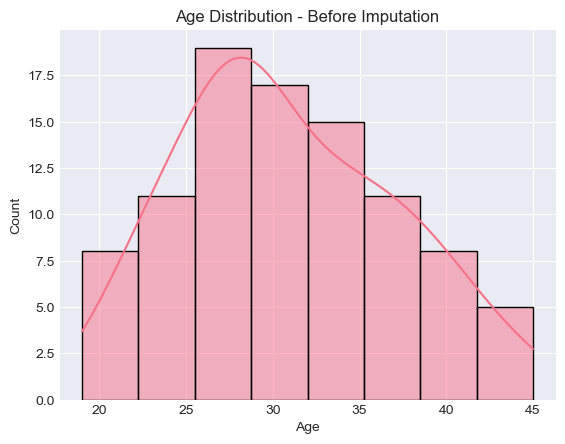

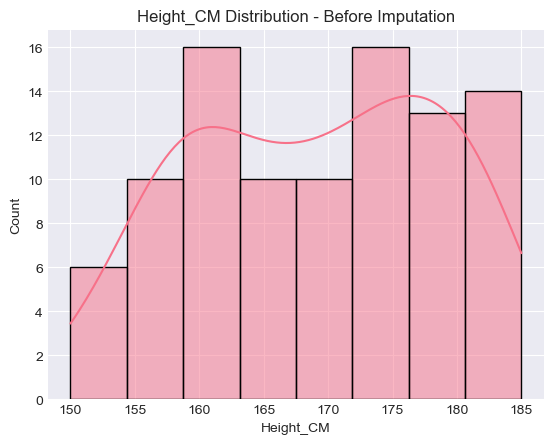

In [64]:
sns.histplot(dataf['Age'],kde=True)
plt.title("Age Distribution - Before Imputation")
plt.show()

sns.histplot(dataf['Height_CM'],kde=True)
plt.title("Height_CM Distribution - Before Imputation")
plt.show()

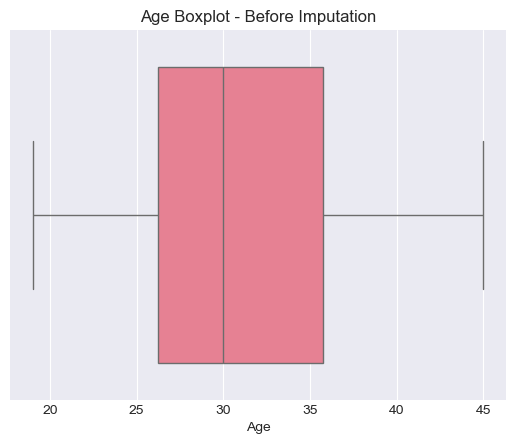

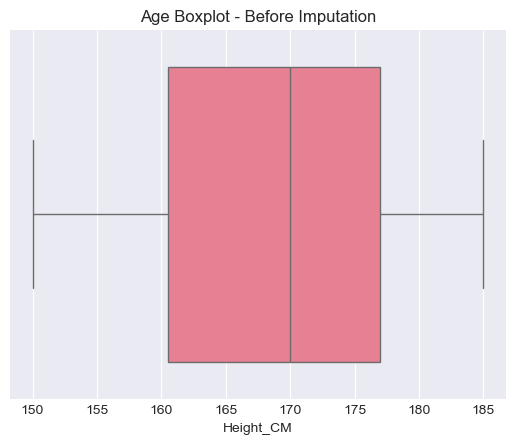

In [65]:
sns.boxplot(x=df['Age'])
plt.title("Age Boxplot - Before Imputation")
plt.show()

sns.boxplot(x=df['Height_CM'])
plt.title("Age Boxplot - Before Imputation")
plt.show()

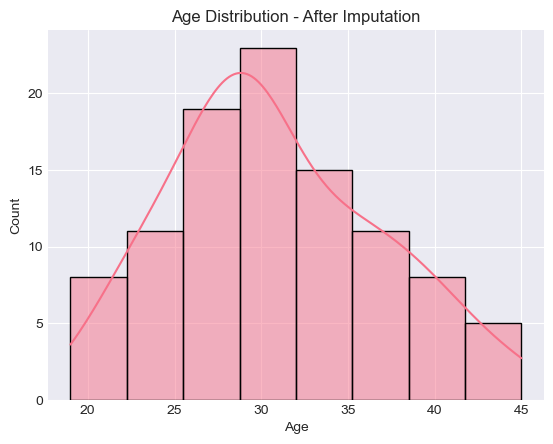

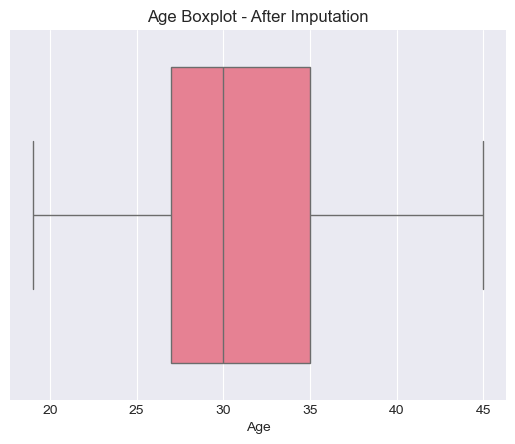

In [68]:
df['Age'].fillna(df['Age'].median(), inplace=True)
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution - After Imputation")
plt.show()

sns.boxplot(x=df['Age'])
plt.title("Age Boxplot - After Imputation")
plt.show()

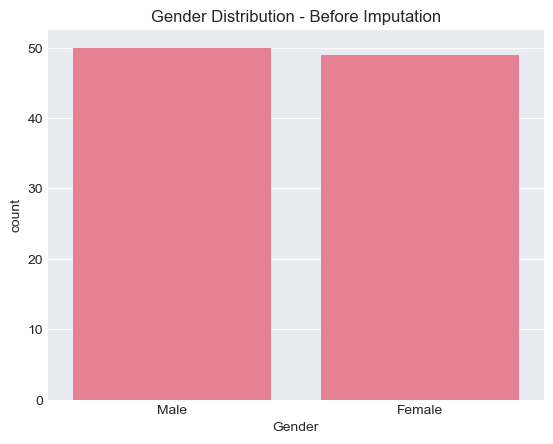

In [69]:
sns.countplot(x=df['Gender'])
plt.title("Gender Distribution - Before Imputation")
plt.show()

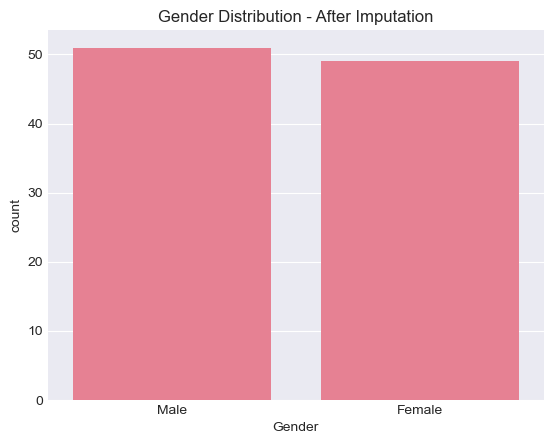

In [70]:
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
sns.countplot(x=df['Gender'])
plt.title("Gender Distribution - After Imputation")
plt.show()